### Google Drive Connection

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [ ]:
!unzip -q images.zip

# Code Section

[INFO] GPU is ready for high-speed training!
Found 21181 images belonging to 3 classes.
Found 5293 images belonging to 3 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
[INFO] Starting training session...
Epoch 1/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 329s 1s/step - accuracy: 0.6529 - loss: 0.7245 - val_accuracy: 0.4670 - val_loss: 1.3733
Epoch 2/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 166s 996ms/step - accuracy: 0.7741 - loss: 0.5048 - val_accuracy: 0.5364 - val_loss: 1.1355
Epoch 3/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.8263 - loss: 0.3980 - val_accuracy: 0.5802 - val_loss: 0.8979
Epoch 4/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.8575 - loss: 0.3403 - val_accuracy: 0.6085 - val_loss: 0.9345
Epoch 5/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.8799 - loss: 0.2889 - val_accuracy: 0.5857 - val_loss: 1.0881
Epoch 6/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.8938 - loss: 0.2597 - val_accuracy: 0.6036 - val_loss: 1.0720
Epoch 

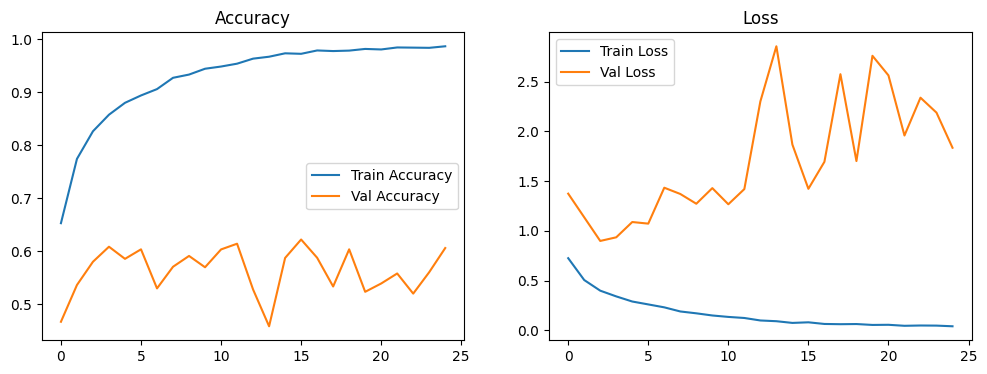

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np

# GPU Configuration
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print("[INFO] GPU is ready for high-speed training!")

# Path Set
DATASET_DIR = '/content/Images'

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 128
EPOCHS = 25

# Data Generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2, # 20% Data validation
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Model Architecture
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.4)(x)
predictions = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Training
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

print("[INFO] Starting training session...")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    verbose=1
)

# Result graph Generation
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

[INFO] Generating predictions for the validation set...
42/42 ━━━━━━━━━━━━━━━━━━━━ 36s 666ms/step

--- Scientific Classification Report ---
              precision    recall  f1-score   support

      100 mV       0.36      0.27      0.31      1912
      150 mV       0.29      0.29      0.29      1472
      175 mV       0.37      0.45      0.41      1909

    accuracy                           0.34      5293
   macro avg       0.34      0.34      0.33      5293
weighted avg       0.34      0.34      0.34      5293



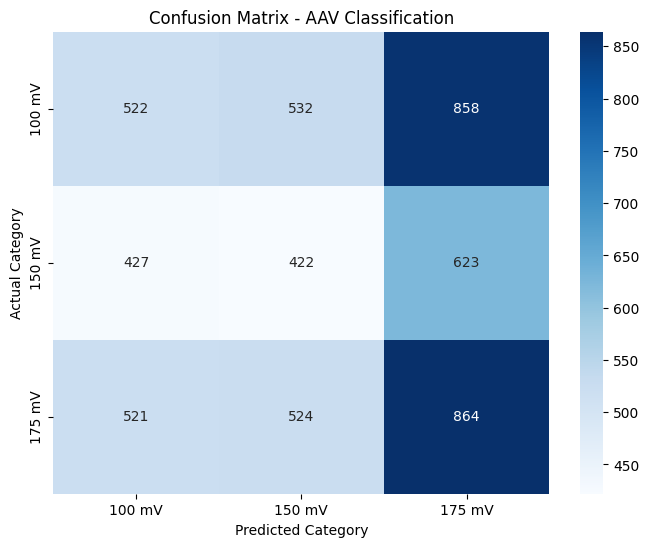

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Validation Data Prediction
print("[INFO] Generating predictions for the validation set...")
# shuffle=False
validation_generator.reset()
Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1)

# Classification Report (Precision, Recall, F1-score)
print('\n--- Scientific Classification Report ---')
target_names = list(train_generator.class_indices.keys())
report = classification_report(validation_generator.classes, y_pred, target_names=target_names)
print(report)

# Confusion Matrix
cm = confusion_matrix(validation_generator.classes, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - AAV Classification')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.show()

In [ ]:
model.save('inceptionv3_aav_model.h5')
print("Model saved successfully!")


Model saved successfully!


In [ ]:

model.save('inceptionv3_aav_model.keras')
print("Model saved in native Keras format successfully!")

Model saved in native Keras format successfully!
